In [9]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('../data/bcn_listings.csv.gz')

In [10]:
df['price'] = df['price'].str.replace("$", "", regex=False)
df['price'] = df['price'].str.replace(",", "", regex=False)
df['price'] = df['price'].astype(float)

In [11]:
areas = ['Eixample', 'Ciutat Vella', 'Gràcia', 'Sarrià-Sant Gervasi']
myquery = (
 "room_type == 'Entire home/apt' "
 "& 1 < accommodates < 7 & "
 "neighbourhood_group_cleansed in @areas")

In [12]:
df["price_person"] = df["price"] / df["accommodates"]

In [5]:
price_pivot = pd.pivot_table(
 df.query(myquery),
 index = "accommodates", # ["accommodates", "another", "other"]
 columns = "neighbourhood_group_cleansed",
 values = "price_person",
 aggfunc = "median")
price_pivot

neighbourhood_group_cleansed,Ciutat Vella,Eixample,Gràcia,Sarrià-Sant Gervasi
accommodates,,,,
2,40.0,73.250000,55.000000,61.000000
3,30.0,54.333333,54.333333,43.000000
4,32.5,54.000000,45.500000,39.500000
5,38.0,50.000000,41.200000,35.200000
6,49.0,47.666667,39.416667,33.333333


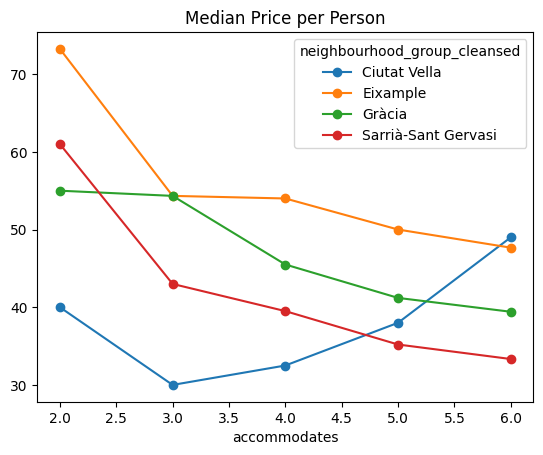

In [13]:
price_pivot.plot(
 kind = "line",
 marker = "o",
 title = "Median Price per Person")
plt.savefig('../reports/graph3.png')
plt.show()